# Capstone Project 1: Analysis of NHANES Body Measurement Data

## Introduction

This report analyses body measurement data from the National Health and
Nutrition Examination Survey (NHANES) for adult male and female participants.
The dataset includes seven measurements per participant: weight, standing
height, upper arm length, upper leg length, arm circumference, hip
circumference, and waist circumference.

Throughout this notebook, the two datasets are loaded as NumPy matrices,
explored using descriptive statistics and visualisations, and used to derive
additional health indicators such as BMI and waist-based ratios.

## 2. Loading the Data

The two CSV files, `nhanes_adult_male_bmx_2020.csv` and
`nhanes_adult_female_bmx_2020.csv`, are read into NumPy matrices named `male`
and `female`, respectively. Each matrix has seven columns corresponding to
the measurements listed above.

In [4]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

# The raw files contain a block of '#'-prefixed comment/description lines
# before the real header and data. comment="#" tells pandas to skip those.
male = pd.read_csv("nhanes_adult_male_bmx_2020.csv", comment="#").to_numpy()
female = pd.read_csv("nhanes_adult_female_bmx_2020.csv", comment="#").to_numpy()

print("Male matrix shape:", male.shape)
print("Female matrix shape:", female.shape)
print("\nFirst 3 rows of male matrix:\n", male[:3])
print("\nFirst 3 rows of female matrix:\n", female[:3])

Male matrix shape: (4081, 7)
Female matrix shape: (4221, 7)

First 3 rows of male matrix:
 [[ 98.8 182.3  42.   40.1  38.2 108.2 120.4]
 [ 74.3 184.2  41.1  41.   30.2  94.5  86.8]
 [103.7 185.3  47.   44.   32.  107.8 109.6]]

First 3 rows of female matrix:
 [[ 97.1 160.2  34.7  40.8  35.8 126.1 117.9]
 [ 91.1 152.7  33.5  33.   38.5 125.5 103.1]
 [ 73.  161.2  37.4  38.   31.8 106.2  92. ]]


The male dataset contains **4,081 participants** and the female dataset contains
**4,221 participants**, each described by seven body measurement variables
(weight, standing height, upper arm length, upper leg length, arm circumference,
hip circumference, and waist circumference).

The raw CSV files included a header
block of descriptive comment lines, which were excluded during loading. A
preliminary inspection of the first few rows confirms that all values fall within
physiologically plausible ranges, with no missing or malformed entries apparent
at this stage.

## 3. Comparing Weight Distributions

To compare the weight distributions of male and female participants, histograms
are plotted for both groups on a shared figure, using identical x-axis limits
to allow for a direct visual comparison.

32.6 180.9
36.8 204.6


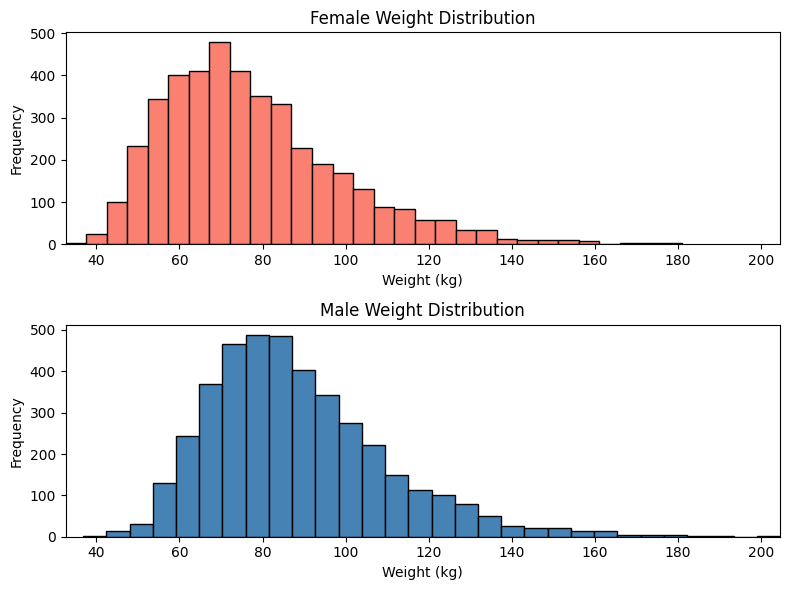

In [5]:
# Column 0 corresponds to weight (kg) in both matrices
female_weight = female[:, 0]
male_weight = male[:, 0]

print(female_weight.min(), female_weight.max())
print(male_weight.min(), male_weight.max())

# Work out shared x-axis limits covering both distributions
xmin = min(female_weight.min(), male_weight.min())
xmax = max(female_weight.max(), male_weight.max())

plt.figure(figsize=(8, 6))

plt.subplot(2, 1, 1)
plt.hist(female_weight, bins=30, color="salmon", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Female Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.subplot(2, 1, 2)
plt.hist(male_weight, bins=30, color="steelblue", edgecolor="black")
plt.xlim(xmin, xmax)
plt.title("Male Weight Distribution")
plt.xlabel("Weight (kg)")
plt.ylabel("Frequency")

plt.tight_layout()
plt.show()

To determine appropriate x-axis limits, the minimum and maximum weight values
were inspected for both groups. The overall minimum (32.6 kg) and maximum
(204.6 kg) across both datasets were then used as shared x-axis limits, ensuring
both histograms are plotted on an identical, data-driven scale.

The female weights range from approximately 32.6 kg to 180.9 kg, while the male
weights range from approximately 36.8 kg to 204.6 kg, with the male maximum
exceeding the female maximum. Both distributions are unimodal and clearly
right-skewed, with a long tail extending towards higher weights rather than a
symmetric bell shape.

The male weight distribution is visibly shifted to the right relative to the
female distribution: its peak (mode) sits around 75-85 kg, compared to roughly
65-70 kg for females, indicating that male participants tend to weigh more on
average. The male distribution also extends further into the upper tail (up to
around 200 kg), whereas the female distribution tapers off earlier (around
160-180 kg). Using identical, data-derived x-axis limits for both panels makes
this rightward shift and the difference in tail length immediately apparent,
supporting a direct visual comparison between the two groups.

## 4. Comparing Weights with a Box-and-Whisker Plot

A box-and-whisker plot is used to compare the male and female weight
distributions side by side, summarising each group's median, interquartile
range, and potential outliers.



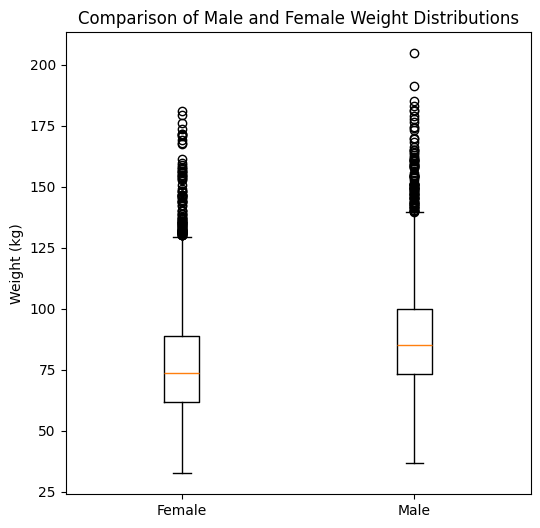

In [6]:
plt.figure(figsize=(6, 6))
plt.boxplot([female_weight, male_weight], tick_labels=["Female", "Male"])
plt.ylabel("Weight (kg)")
plt.title("Comparison of Male and Female Weight Distributions")
plt.show()

The box-and-whisker plot confirms the pattern observed in the histograms: the
median male weight (approximately 85 kg) is clearly higher than the median
female weight (approximately 73 kg). The male box is also shifted upward, with
an interquartile range spanning roughly 73-100 kg, compared to roughly 62-89 kg
for females, and the two boxes show only partial overlap.

The two interquartile ranges are of similar width (around 27 kg each),
suggesting that the "typical" spread of weights in the middle 50% of each group
is comparable, despite males being centred at a higher value overall. Both
distributions display a substantial number of outliers above the upper whisker
(beyond roughly 130 kg), consistent with the right-skewed shape seen in the
histograms. Notably, the single most extreme outlier (around 205 kg) belongs to
the male group, indicating that the heaviest individual in the combined sample
is male. Overall, the plot supports the conclusion that male participants tend
to weigh more than female participants, while both groups share a similar
degree of variability in their central range and a long tail of heavier
individuals.

## 5. Numerical Aggregates of Weight Distributions

To complement the visual comparison, basic numerical aggregates — measures of
location, dispersion, and shape — are computed for the male and female weight
# distributions.

In [7]:
import pandas as pd

def summarize_pd(data, label):
    s = pd.Series(data)
    print(f"--- {label} ---")
    print(s.describe())
    print(f"Variance:          {s.var():.2f}")
    print(f"Range:             {s.max() - s.min():.2f}")
    print(f"IQR:               {s.quantile(0.75) - s.quantile(0.25):.2f}")
    print(f"Skewness:          {s.skew():.3f}")
    print(f"Kurtosis (excess): {s.kurt():.3f}")
    print()

summarize_pd(female_weight, "Female Weight")
summarize_pd(male_weight, "Male Weight")

--- Female Weight ---
count    4221.000000
mean       77.403791
std        21.545061
min        32.600000
25%        61.600000
50%        73.600000
75%        88.700000
max       180.900000
dtype: float64
Variance:          464.19
Range:             148.30
IQR:               27.10
Skewness:          1.034
Kurtosis (excess): 1.404

--- Male Weight ---
count    4081.000000
mean       88.364543
std        21.421561
min        36.800000
25%        73.300000
50%        85.000000
75%        99.800000
max       204.600000
dtype: float64
Variance:          458.88
Range:             167.80
IQR:               26.50
Skewness:          0.985
Kurtosis (excess): 1.478



Both weight distributions are right-skewed (not left-skewed), as shown by their
positive skewness values (female: 1.034; male: 0.985) and by the mean exceeding
the median in both groups. This means most participants weigh close to a
moderate value, with a smaller number of considerably heavier individuals
pulling the mean upward.

In terms of location, male participants weigh more on average than female
participants, with a mean of 88.36 kg versus 77.40 kg, and a median of 85.00 kg
versus 73.60 kg — a difference of roughly 11 kg at both measures.

In terms of dispersion, the two groups are very similar: the female standard
deviation (21.55) and IQR (27.10) are only marginally higher than the male
standard deviation (21.42) and IQR (26.50). So although males weigh more on
average, both sexes show a comparable degree of variability around their
respective centres. The male distribution has a wider overall range (167.80 kg
vs. 148.30 kg), reflecting the presence of an extreme high-weight outlier.

Both distributions also show positive excess kurtosis (female: 1.404; male:
1.478), indicating heavier tails than a normal distribution — consistent with
the outliers seen in the box-and-whisker plot for both groups.

## 6. Adding Body Mass Index (BMI) to the Female Dataset

Body Mass Index (BMI) is calculated as:

$$
BMI = \frac{\text{Weight (kg)}}{\text{Height (m)}^2}
$$

This measure is computed for each female participant and appended as an eighth column to the `female` matrix.

In [19]:
# Step 1 cell — re-run this first to reset female to 7 columns
female = pd.read_csv("nhanes_adult_female_bmx_2020.csv", comment="#").to_numpy()

In [20]:
# Column 0 = weight (kg), Column 1 = height (cm)
weight_col = female[:, 0]
height_m = female[:, 1] / 100  # convert cm to metres
print("Old female matrix shape:", female.shape)

bmi = weight_col / (height_m ** 2)

# Append BMI as an 8th column
female = np.column_stack((female, bmi))

print("New female matrix shape:", female.shape)
print("\nFirst 5 rows (last column is BMI):\n", female[:5])

Old female matrix shape: (4221, 7)
New female matrix shape: (4221, 8)

First 5 rows (last column is BMI):
 [[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496]
 [ 61.7        157.4         38.          34.7         29.
  101.          90.5         24.90437849]
 [ 55.4        154.6         34.6         34.          28.3
   92.5         73.2         23.17879132]]


The `female` matrix now contains eight columns, with the newly added eighth
column representing each participant's BMI. A visual check of the first few
rows confirms that the computed BMI values (e.g., approximately 37.8, 39.1, and
28.1 for the first three participants) fall within a physiologically plausible
range, supporting the correctness of the calculation.

## 7. Standardising the Female Dataset

To place all variables on a common scale for comparison, each column of the
`female` matrix (including the newly added BMI column) is standardised by
computing its z-score: subtracting the column mean and dividing by the column
standard deviation. The result is stored in a new matrix, `zfemale`.

In [9]:
# Standardise each column: (value - column mean) / column std
col_means = female.mean(axis=0)
col_stds = female.std(axis=0, ddof=1)

zfemale = (female - col_means) / col_stds

print("zfemale shape:", zfemale.shape)
print("\nColumn means of zfemale:\n", zfemale.mean(axis=0))
print("\nColumn std devs of zfemale:\n", zfemale.std(axis=0, ddof=1))
print("\nFirst 5 rows of zfemale:\n", zfemale[:5])

zfemale shape: (4221, 8)

Column means of zfemale:
 [-2.08735606e-16  1.89208727e-15  7.69291709e-16  5.70656213e-16
 -3.36670332e-18  5.62239454e-16 -8.58509347e-16  1.41401539e-16]

Column std devs of zfemale:
 [1. 1. 1. 1. 1. 1. 1. 1.]

First 5 rows of zfemale:
 [[ 0.91418677  0.00894932 -0.56732742  1.13285382  0.55078021  1.08303325
   1.11565244  0.9968496 ]
 [ 0.63570067 -1.05294368 -1.07880364 -1.29333838  1.03209576  1.04463152
   0.26505759  1.15603786]
 [-0.20439908  0.15053505  0.58349407  0.26191303 -0.16227987 -0.1906243
  -0.37288855 -0.2592443 ]
 [-0.72888124 -0.38749073  0.83923218 -0.7645529  -0.66142193 -0.52343933
  -0.45909748 -0.67031143]
 [-1.02129166 -0.78393078 -0.60995044 -0.98228809 -0.78620744 -1.06746392
  -1.4533739  -0.89279282]]


The standardised matrix `zfemale` has the same dimensions as `female`
(4221 rows, 8 columns). As confirmed by the output, the mean of each
standardised column is approximately zero (on the order of 1e-16, attributable
to floating-point rounding) and the standard deviation of each column is
exactly one, verifying that the z-score transformation was applied correctly.
This standardisation places all eight variables — including measurements
originally on very different scales, such as height in centimetres and BMI as
a dimensionless ratio — onto a common scale, enabling fair comparison across
variables in the subsequent pairplot and correlation analysis.

## 8. Relationships Between Standardised Female Variables

A scatterplot matrix (pairplot) is drawn for the standardised height, weight,
waist circumference, hip circumference, and BMI of the female participants,
based on `zfemale`. Pearson's and Spearman's correlation coefficients are
computed for every pair of these variables to quantify the strength and nature
of their relationships.

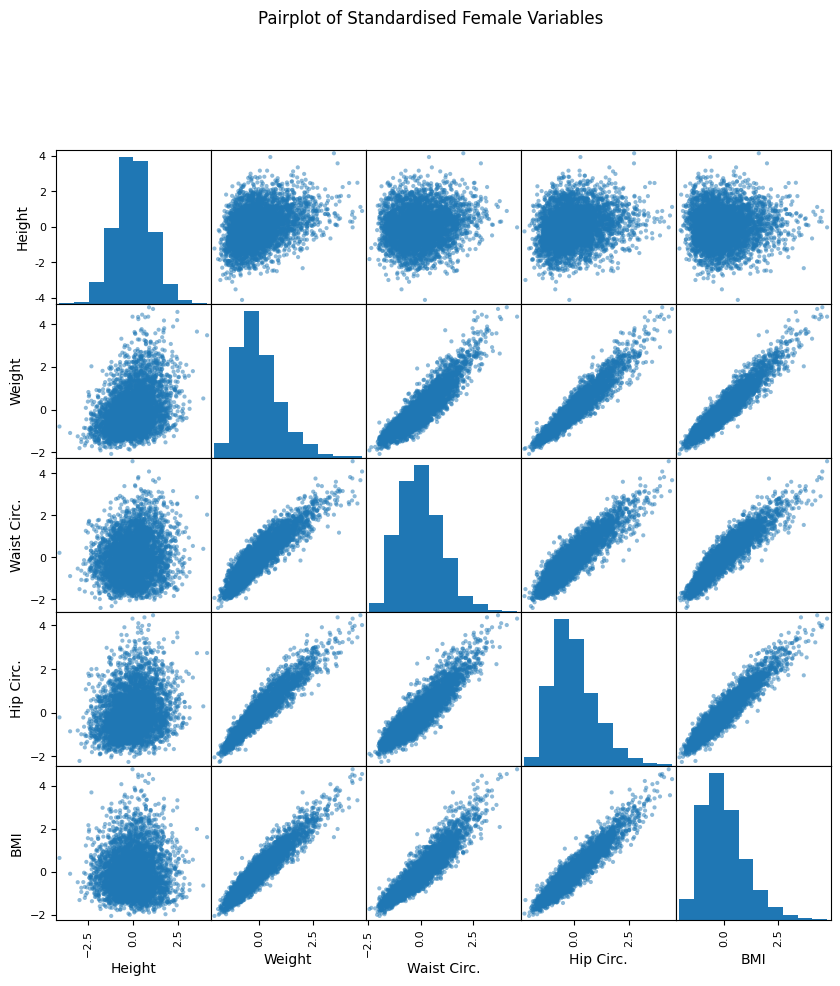

Pearson correlation matrix:
              Height  Weight  Waist Circ.  Hip Circ.    BMI
Height        1.000   0.345        0.127      0.203  0.033
Weight        0.345   1.000        0.905      0.947  0.946
Waist Circ.   0.127   0.905        1.000      0.897  0.921
Hip Circ.     0.203   0.947        0.897      1.000  0.944
BMI           0.033   0.946        0.921      0.944  1.000

Spearman correlation matrix:
              Height  Weight  Waist Circ.  Hip Circ.    BMI
Height        1.000   0.339        0.109      0.205  0.020
Weight        0.339   1.000        0.900      0.947  0.938
Waist Circ.   0.109   0.900        1.000      0.888  0.923
Hip Circ.     0.205   0.947        0.888      1.000  0.934
BMI           0.020   0.938        0.923      0.934  1.000


In [10]:
import pandas as pd
from pandas.plotting import scatter_matrix
from scipy import stats

# Column indices in female/zfemale:
# 0=weight, 1=height, 2=upper arm, 3=upper leg, 4=arm circ, 5=hip circ, 6=waist circ, 7=BMI
selected_cols = [1, 0, 6, 5, 7]
col_names = ["Height", "Weight", "Waist Circ.", "Hip Circ.", "BMI"]

zfemale_subset = pd.DataFrame(zfemale[:, selected_cols], columns=col_names)

# Scatterplot matrix
scatter_matrix(zfemale_subset, figsize=(10, 10), diagonal="hist")
plt.suptitle("Pairplot of Standardised Female Variables", y=1.02)
plt.show()

# Pearson correlation matrix
pearson_corr = zfemale_subset.corr(method="pearson")
print("Pearson correlation matrix:\n", pearson_corr.round(3))

# Spearman correlation matrix
spearman_corr = zfemale_subset.corr(method="spearman")
print("\nSpearman correlation matrix:\n", spearman_corr.round(3))

The analysis shows that weight, waist circumference, hip circumference, and BMI are strongly positively correlated, with Pearson correlations ranging from 0.897 to 0.947. This means participants with higher weight generally have larger waist/hip measurements and higher BMI.

Height has much weaker relationships with the other variables, with correlations ranging from 0.033 to 0.345.

Pearson and Spearman correlations are also very similar, suggesting that these relationships are mostly linear and monotonic, with little evidence of non-linearity.

Overall: Body-size measures (weight, waist, hip, BMI) form a strongly interconnected group, while height is comparatively weakly related to them.

## 9. Waist-to-Height and Waist-to-Hip Ratios

Two additional body-shape indicators are computed for both male and female
participants: the waist-to-height ratio and the waist-to-hip ratio. These are
appended as two new columns to the `male` and `female` matrices, respectively.

In [11]:
# Male
male_wthr = male[:, 6] / male[:, 1]   # waist / height
male_whr  = male[:, 6] / male[:, 5]   # waist / hip
male = np.column_stack((male, male_wthr, male_whr))

# Female
female_wthr = female[:, 6] / female[:, 1]   # waist / height
female_whr  = female[:, 6] / female[:, 5]   # waist / hip
female = np.column_stack((female, female_wthr, female_whr))

print("New male shape:", male.shape)
print("New female shape:", female.shape)
print("\nFirst 3 rows of male (last 2 cols = WtHR, WHR):\n", male[:3])
print("\nFirst 3 rows of female (last 2 cols = WtHR, WHR):\n", female[:3])

New male shape: (4081, 9)
New female shape: (4221, 10)

First 3 rows of male (last 2 cols = WtHR, WHR):
 [[ 98.8        182.3         42.          40.1         38.2
  108.2        120.4          0.66044981   1.11275416]
 [ 74.3        184.2         41.1         41.          30.2
   94.5         86.8          0.47122693   0.91851852]
 [103.7        185.3         47.          44.          32.
  107.8        109.6          0.59147329   1.01669759]]

First 3 rows of female (last 2 cols = WtHR, WHR):
 [[ 97.1        160.2         34.7         40.8         35.8
  126.1        117.9         37.83504078   0.73595506   0.93497224]
 [ 91.1        152.7         33.5         33.          38.5
  125.5        103.1         39.06972037   0.67518009   0.82151394]
 [ 73.         161.2         37.4         38.          31.8
  106.2         92.          28.09265496   0.5707196    0.86629002]]


Two new columns were appended to both the `male` and `female` matrices: the
waist-to-height ratio and the waist-to-hip ratio. The `male` matrix now has
nine columns and the `female` matrix has ten columns (reflecting the earlier
addition of BMI). A check of the first few rows confirms that both ratios fall
within physiologically plausible ranges — for example, waist-to-height ratios
of approximately 0.47-0.74 and waist-to-hip ratios of approximately 0.82-1.11
across the sampled rows — supporting the correctness of the calculations.

## 10. Comparing Waist-to-Height and Waist-to-Hip Ratios

A box-and-whisker plot with four boxes is used to compare the distributions of
the waist-to-height ratio and the waist-to-hip ratio between male and female
participants.

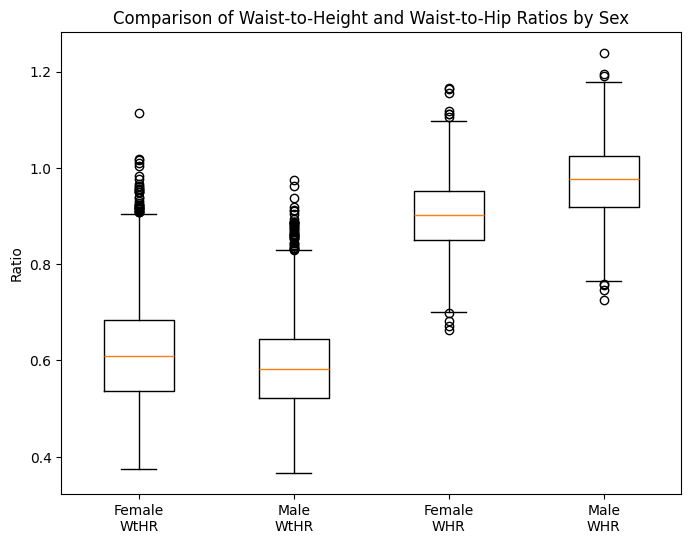

In [12]:
# Extract the four ratio vectors
male_wthr   = male[:, 7]
male_whr    = male[:, 8]
female_wthr = female[:, 8]
female_whr  = female[:, 9]

plt.figure(figsize=(8, 6))
plt.boxplot(
    [female_wthr, male_wthr, female_whr, male_whr],
    tick_labels=["Female\nWtHR", "Male\nWtHR", "Female\nWHR", "Male\nWHR"]
)
plt.ylabel("Ratio")
plt.title("Comparison of Waist-to-Height and Waist-to-Hip Ratios by Sex")
plt.show()

The **waist-to-height ratio (WtHR)** is similar for males and females, with medians of approximately **0.58 and 0.61**, and substantial overlap between the distributions.
The **waist-to-hip ratio (WHR)** shows a much clearer difference: males have a higher median (**~0.98**) than females (**~0.90**), with less overlap.

WtHR does not strongly distinguish between sexes in this dataset, whereas **WHR is a much stronger sex-discriminating measure**. Both measures also contain some outliers.


## 11. Advantages and Disadvantages of BMI, Waist-to-Height Ratio, and Waist-to-Hip Ratio

### Body Mass Index (BMI)

**Advantages:**

* Simple to calculate using only weight and height.
* Inexpensive and non-invasive.
* Widely used, making it useful for comparing populations and tracking trends.

**Disadvantages:**

* Does not distinguish between muscle mass and fat mass.
* May classify muscular individuals as overweight.
* Does not account for body-fat distribution, particularly abdominal fat.
* May behave inconsistently for very short or very tall individuals.

---

### Waist-to-Height Ratio (WtHR)

**Advantages:**

* Simple to calculate using waist circumference and height.
* Provides an indication of central obesity.
* Can provide more information about fat distribution than BMI.

**Disadvantages:**

* Does not capture muscle mass, bone density, or overall body composition.
* Waist circumference measurements can vary depending on tape placement.
* Relies on only two measurements.

---

### Waist-to-Hip Ratio (WHR)

**Advantages:**

* Captures body-fat distribution and overall body shape.
* Can indicate cardiovascular and metabolic risk.
* Shows clearer differences between male and female body shapes in this dataset.

**Disadvantages:**

* Requires two circumference measurements, increasing the possibility of measurement error.
* Does not directly measure overall body fat or excess weight.
* A healthy WHR does not necessarily mean a person has a healthy body-fat percentage.

---

### Summary

BMI is the simplest measure but provides limited information about fat distribution. WtHR and WHR provide additional information about body-fat distribution, with WHR showing clearer differences between males and females in this dataset. **Using all three measures together provides a more complete picture than relying on any single measure.**

## 12. Standardised Measurements for Extreme BMI Cases

To examine individuals at the extremes of the BMI distribution, the
standardised measurements (from `zfemale`) for the five female participants
with the lowest BMI and the five with the highest BMI are identified using
`numpy.argsort` and printed for inspection.

In [14]:
col_labels = ["Weight", "Height", "Upper Arm", "Upper Leg",
              "Arm Circ.", "Hip Circ.", "Waist Circ.", "BMI"]

# Column 7 of zfemale is BMI
bmi_order = np.argsort(zfemale[:, 7])

lowest5_idx  = bmi_order[:5]
highest5_idx = bmi_order[-5:]

print("5 Lowest-BMI Participants (standardised)")
print(pd.DataFrame(zfemale[lowest5_idx], columns=col_labels).round(2))

print("\n5 Highest-BMI Participants (standardised)")
print(pd.DataFrame(zfemale[highest5_idx], columns=col_labels).round(2))

5 Lowest-BMI Participants (standardised)
   Weight  Height  Upper Arm  Upper Leg  Arm Circ.  Hip Circ.  Waist Circ.  \
0   -2.08   -1.22      -1.55      -1.17      -2.19      -2.04        -1.94   
1   -1.88   -0.19      -1.72       0.39      -2.44      -1.85        -2.06   
2   -1.54    1.81       0.63       0.57      -2.27      -1.68        -1.71   
3   -1.84   -0.26      -0.23       0.51      -2.30      -2.25        -1.86   
4   -1.61    0.89      -0.10       0.48      -2.21      -1.83        -1.71   

    BMI  
0 -2.05  
1 -1.99  
2 -1.97  
3 -1.94  
4 -1.89  

5 Highest-BMI Participants (standardised)
   Weight  Height  Upper Arm  Upper Leg  Arm Circ.  Hip Circ.  Waist Circ.  \
0    4.25    0.29       1.86      -0.98       2.37       4.10         3.82   
1    4.46    0.50       1.69      -1.14       3.35       3.98         2.90   
2    4.35    0.28       2.84       1.94       4.37       3.92         3.75   
3    4.80    0.89       2.12       1.82       3.78       4.02         4.08 

The **five participants with the lowest BMI** have strongly negative standardized values for weight, waist, hip, and arm circumference, showing that they are generally smaller in body size.
The **five participants with the highest BMI** show strongly positive standardized values for these same measurements, especially weight and hip circumference.

In contrast, **height shows much smaller and inconsistent standardized values** in both groups. This supports the earlier finding that height has a very weak relationship with BMI (**r = 0.033**).

BMI in this dataset is influenced mainly by **weight and body-circumference measurements**, while **height has little influence** on the extreme BMI cases.


## Conclusion

This analysis examined body measurement data from **4,081 male and 4,221 female adults** from the NHANES dataset and identified several important patterns.

1. **Sex-based differences:** Male participants had a higher average weight than females (**88.36 kg vs. 77.40 kg**). While waist-to-height ratios were broadly similar, the **waist-to-hip ratio showed a clearer difference between males and females**, reflecting differences in body-fat distribution.

2. **Relationships between variables:** Weight, waist circumference, hip circumference, and BMI showed **strong positive correlations**, while height had a much weaker relationship with these measures and was almost uncorrelated with BMI (**r = 0.033**).

3. **Body composition measures:** BMI, waist-to-height ratio, and waist-to-hip ratio each provide different information. In this dataset, **waist-to-hip ratio was the most sex-discriminating measure**, while BMI provided a simple measure of overall body size.

**Overall,** the analysis demonstrates that no single anthropometric measure provides a complete picture of body composition. Combining **BMI with circumference-based measures** provides a more informative assessment of body size and fat distribution.
